In [14]:
# ==============================================================================
# CELL 1: CÀI ĐẶT & ĐỊNH NGHĨA MÔI TRƯỜNG (ĐÃ FIX LỖI HIỂN THỊ TÀI SẢN)
# ==============================================================================
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git -q
!pip install shimmy>=0.2.1 -q
!pip install pandas numpy matplotlib yfinance -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import yfinance as yf
from stable_baselines3 import PPO, A2C, DDPG
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

class StockTradingEnvVietnam(StockTradingEnv):
    def __init__(self,
                 buy_cost_pct=0.0015, sell_cost_pct=0.0015, sell_tax_pct=0.001,
                 min_trading_lot=100, settlement_cycle=3, **kwargs):

        # Tạo num_stock_shares mặc định nếu thiếu
        if 'num_stock_shares' not in kwargs:
            stock_dim = kwargs.get('stock_dim')
            kwargs['num_stock_shares'] = [0] * stock_dim

        # Truyền phí vào kwargs cho class cha
        kwargs['buy_cost_pct'] = buy_cost_pct
        kwargs['sell_cost_pct'] = sell_cost_pct

        super().__init__(**kwargs)

        self.sell_tax_pct = sell_tax_pct
        self.min_trading_lot = min_trading_lot
        self.settlement_cycle = settlement_cycle

        # Kho hàng chờ & Tiền chờ
        self.stocks_pending = np.zeros((self.stock_dim, self.settlement_cycle))
        self.cash_pending = np.zeros(self.settlement_cycle)

    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        self.stocks_pending = np.zeros((self.stock_dim, self.settlement_cycle))
        self.cash_pending = np.zeros(self.settlement_cycle)
        return obs, info

    def _update_settlement(self):
        # 1. Tiền về
        self.state[0] += self.cash_pending[-1]
        self.cash_pending = np.roll(self.cash_pending, 1); self.cash_pending[0] = 0

        # 2. Cổ phiếu về
        for i in range(self.stock_dim):
            self.state[self.stock_dim + 1 + i] += self.stocks_pending[:, -1][i]
        self.stocks_pending = np.roll(self.stocks_pending, 1, axis=1); self.stocks_pending[:, 0] = 0

    def step(self, actions):
        # 1. Cập nhật T+ (Hàng/Tiền về)
        self._update_settlement()

        # 2. Gọi hàm step gốc để thực hiện giao dịch (Mua/Bán)
        obs, reward, done, truncated, info = super().step(actions)

        # 3. ########## FIX LỖI HIỂN THỊ TÀI SẢN (QUAN TRỌNG) ##########
        # Logic cũ của FinRL chỉ tính: Tiền mặt + Giá trị Cổ phiếu khả dụng
        # Chúng ta cần cộng thêm: Tiền đang chờ về + Giá trị Cổ phiếu đang chờ về

        # a. Lấy giá hiện tại (Close price)
        close_prices = np.array([self.state[i + 1] for i in range(self.stock_dim)])

        # b. Tính giá trị cổ phiếu đang chờ (Pending Stocks)
        # stocks_pending là ma trận [Số mã, Số ngày]. Ta sum theo hàng ngang để lấy tổng cổ phiếu chờ của từng mã
        total_pending_shares = np.sum(self.stocks_pending, axis=1)
        value_pending_stocks = np.sum(total_pending_shares * close_prices)

        # c. Tính tiền đang chờ (Pending Cash)
        value_pending_cash = np.sum(self.cash_pending)

        # d. Tính lại tổng tài sản thực tế
        # self.asset_memory[-1] là giá trị cũ bị sai, ta lấy nó ra để sửa
        # Giá trị cũ = Tiền mặt + CP Khả dụng. Ta chỉ cần cộng thêm phần Pending
        true_asset_value = self.asset_memory[-1] + value_pending_stocks + value_pending_cash

        # e. Ghi đè lại vào bộ nhớ
        self.asset_memory[-1] = true_asset_value

        # (Tùy chọn) Cập nhật lại reward nếu cần, nhưng để test thì sửa asset_memory là đủ để vẽ biểu đồ đúng.
        ################################################################

        return obs, reward, done, truncated, info

    def _sell_stock(self, index, action):
        available = self.state[index + self.stock_dim + 1]
        if available > 0:
            share = min(abs(action) // self.min_trading_lot * self.min_trading_lot, available)
            if share > 0:
                income = self.state[index+1] * share * (1 - (self.sell_cost_pct + self.sell_tax_pct))
                self.cash_pending[0] += income # Tiền vào kho chờ
                self.state[index + self.stock_dim + 1] -= share
                self.trades += 1
                return share
        return 0

    def _buy_stock(self, index, action):
        share = action // self.min_trading_lot * self.min_trading_lot
        if share > 0:
            cost = self.state[index+1] * share * (1 + self.buy_cost_pct)
            if self.state[0] >= cost:
                self.state[0] -= cost
                self.stocks_pending[index][0] += share # Cổ phiếu vào kho chờ
                self.trades += 1
                return share
        return 0

print("✅ Đã cập nhật môi trường: Sửa lỗi hiển thị tài sản khi bị kẹp T+.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
✅ Đã cập nhật môi trường: Sửa lỗi hiển thị tài sản khi bị kẹp T+.


In [15]:
# ==============================================================================
# CELL 2: LOAD DỮ LIỆU TEST (2024-2025)
# ==============================================================================
if os.path.exists("vietnam_vn30_data.csv"):
    df = pd.read_csv("vietnam_vn30_data.csv")
    df['date'] = pd.to_datetime(df['date'])

    # Lấy dữ liệu từ 2024 để kiểm tra (AI chưa từng thấy dữ liệu này)
    test_df = df[df.date >= '2024-01-01'].copy()
    test_df = test_df.sort_values(['date', 'tic']).reset_index(drop=True)
    test_df.index = test_df['date'].factorize()[0]

    print(f"📊 Dữ liệu Test: {len(test_df)} dòng (2024 - Nay).")

    # Cấu hình môi trường Test
    stock_dimension = len(test_df.tic.unique())
    INDICATORS_LIST = ['macd', 'rsi_30', 'cci_30', 'dx_30']
    state_space = 1 + 2*stock_dimension + len(INDICATORS_LIST)*stock_dimension

    env_kwargs = {
        "hmax": 5000, "initial_amount": 1000000000,
        "buy_cost_pct": 0.0015, "sell_cost_pct": 0.0015, "sell_tax_pct": 0.001,
        "min_trading_lot": 100, "settlement_cycle": 3,
        "state_space": state_space, "stock_dim": stock_dimension,
        "tech_indicator_list": INDICATORS_LIST, "action_space": stock_dimension,
        "reward_scaling": 1e-4
    }
else:
    print("❌ THIẾU FILE DATA! Hãy upload 'vietnam_vn30_data.csv'.")

📊 Dữ liệu Test: 14730 dòng (2024 - Nay).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🚀 BẮT ĐẦU CUỘC ĐUA...
🤖 Đang chạy PPO... ✅ Xong (Tài sản cuối: 1,051,356,272)
🤖 Đang chạy A2C... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Xong (Tài sản cuối: 1,639,159,211)
🤖 Đang chạy DDPG... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^VNINDEX']: YFTzMissingError('possibly delisted; no timezone found')


✅ Xong (Tài sản cuối: 2,159,426,015)

📉 Đang tải VN-INDEX làm tham chiếu...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


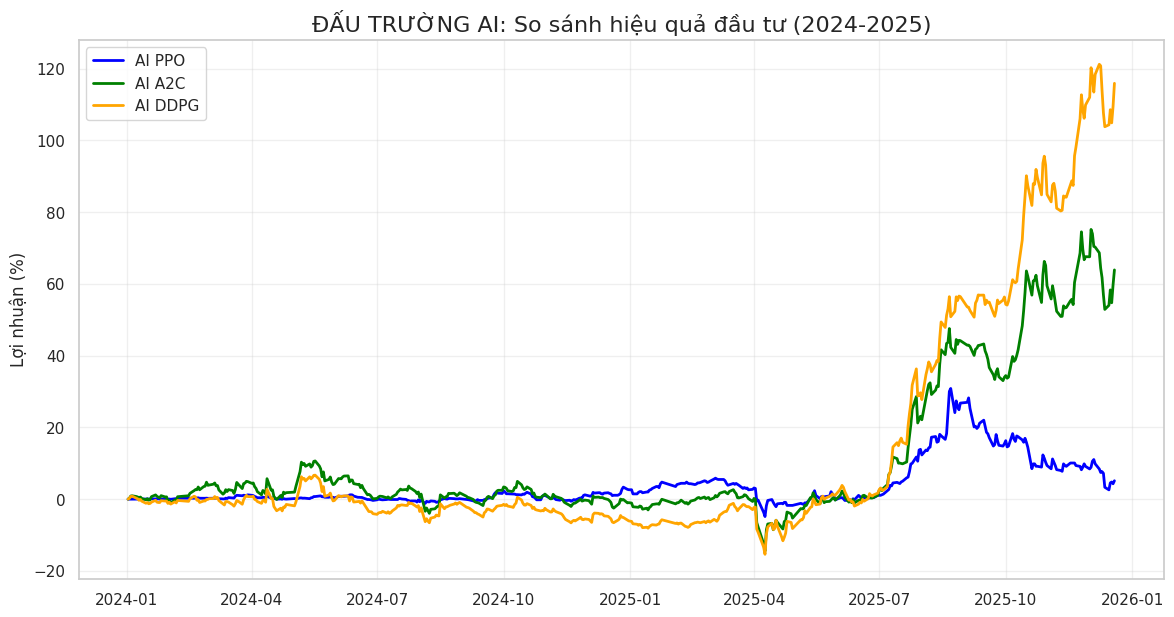

In [16]:
# ==============================================================================
# CELL 3: CHẠY BACKTEST & SO SÁNH VỚI VNINDEX
# ==============================================================================
models = {
    "PPO": ("ppo_vn_agent", PPO),
    "A2C": ("a2c_vn_agent", A2C),
    "DDPG": ("ddpg_vn_agent", DDPG)
}

results = {}

print("🚀 BẮT ĐẦU CUỘC ĐUA...")

# 1. Chạy từng Model
for name, (path, model_class) in models.items():
    if os.path.exists(f"{path}.zip"):
        print(f"🤖 Đang chạy {name}...", end=" ")
        e_test_gym = StockTradingEnvVietnam(df=test_df, **env_kwargs)
        model = model_class.load(path)

        state, info = e_test_gym.reset()
        done = False
        while not done:
            action, _ = model.predict(state, deterministic=True)
            state, rewards, done, truncated, info = e_test_gym.step(action)

        df_res = pd.DataFrame(e_test_gym.asset_memory, columns=['account_value'])
        results[name] = df_res['account_value'].values
        print(f"✅ Xong (Tài sản cuối: {df_res['account_value'].iloc[-1]:,.0f})")
    else:
        print(f"⚠️ Thiếu file {name}")

# 2. Lấy dữ liệu VNINDEX thực tế
print("\n📉 Đang tải VN-INDEX làm tham chiếu...")
try:
    vnindex = yf.download("^VNINDEX", start="2024-01-01", end="2025-12-31", ignore_tz=True)['Close']
    vnindex = vnindex.reset_index()
    vnindex.columns = ['date', 'vnindex']
except:
    vnindex = pd.DataFrame()

# 3. Vẽ biểu đồ so sánh
unique_dates = test_df.date.unique()
df_plot = pd.DataFrame({'date': unique_dates})

plt.figure(figsize=(14, 7))

# Vẽ các đường AI
colors = {'PPO': 'blue', 'A2C': 'green', 'DDPG': 'orange'}
for name, values in results.items():
    # Cắt gọt cho khớp độ dài
    if len(values) > len(df_plot): values = values[:len(df_plot)]
    if len(values) < len(df_plot): values = np.pad(values, (0, len(df_plot)-len(values)), 'edge')

    # Tính % lợi nhuận
    returns = (values / 1_000_000_000 - 1) * 100
    plt.plot(df_plot['date'], returns, label=f'AI {name}', color=colors.get(name), linewidth=2)

# Vẽ VNINDEX
if not vnindex.empty:
    df_plot = df_plot.merge(vnindex, on='date', how='left').ffill()
    base_idx = df_plot['vnindex'].iloc[0]
    idx_returns = (df_plot['vnindex'] / base_idx - 1) * 100
    plt.plot(df_plot['date'], idx_returns, label='VN-Index', color='red', linestyle='--', linewidth=2, alpha=0.7)

plt.title("ĐẤU TRƯỜNG AI: So sánh hiệu quả đầu tư (2024-2025)", fontsize=16)
plt.ylabel("Lợi nhuận (%)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

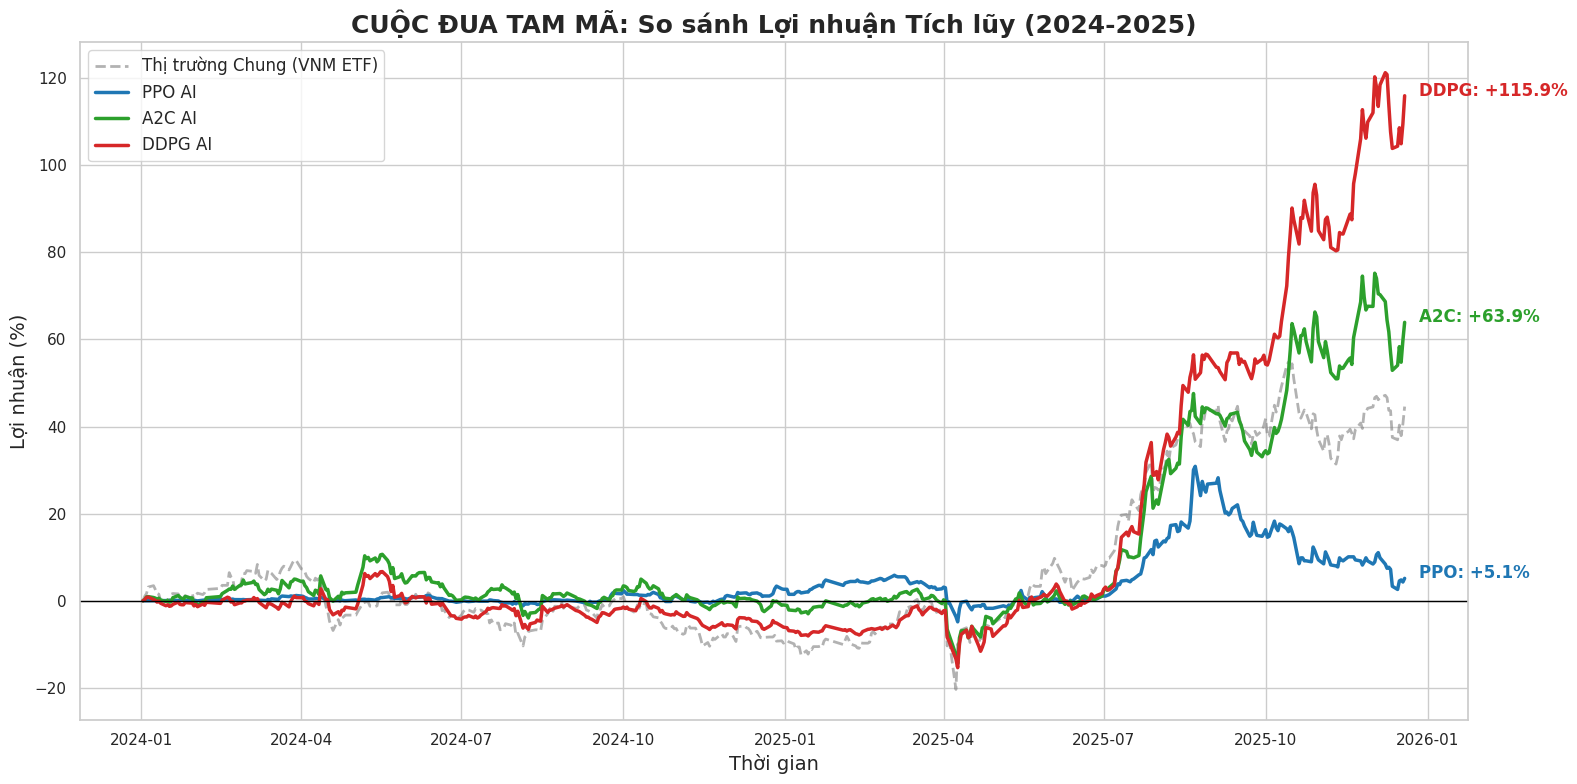

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
# ==============================================================================
# CELL 5: VẼ BIỂU ĐỒ SO SÁNH 3 MODEL QUA THỜI GIAN
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
...
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Cấu hình giao diện đẹp
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)

# 1. Chuẩn bị dữ liệu vẽ
# Lấy danh sách ngày từ dữ liệu test
dates = test_df.date.unique()
initial_capital = 1_000_000_000 # 1 Tỷ VND

# Tạo DataFrame chứa % lợi nhuận
df_plot = pd.DataFrame({'date': dates})

# Xử lý dữ liệu của từng Model
for name, values in results.items():
    # Cắt hoặc thêm (Pad) dữ liệu cho khớp độ dài ngày
    if len(values) > len(df_plot):
        values = values[:len(df_plot)]
    elif len(values) < len(df_plot):
        values = np.pad(values, (0, len(df_plot)-len(values)), 'edge')

    # Tính % lợi nhuận tích lũy: (Vốn hiện tại / Vốn gốc - 1) * 100
    df_plot[name] = (values / initial_capital - 1) * 100

# 2. Xử lý Benchmark (Nếu đã tải được ở bước trước)
# (Biến 'benchmark_data' lấy từ Cell trước, nếu chưa có thì bỏ qua)
try:
    if 'benchmark_data' in globals() and not benchmark_data.empty:
        # Merge theo ngày
        benchmark_data['date'] = pd.to_datetime(benchmark_data['date']).dt.tz_localize(None)
        df_plot = df_plot.merge(benchmark_data, on='date', how='left').ffill().bfill()

        # Tính % cho Benchmark
        base_price = df_plot['benchmark'].iloc[0]
        df_plot['Market (ETF/Index)'] = (df_plot['benchmark'] / base_price - 1) * 100
except:
    pass

# 3. VẼ BIỂU ĐỒ
plt.figure(figsize=(16, 8))

# Màu sắc phân biệt
colors = {'PPO': '#1f77b4', 'A2C': '#2ca02c', 'DDPG': '#d62728'} # Xanh, Lục, Đỏ (DDPG màu đỏ nổi bật)

# Vẽ đường Market trước (nét đứt mờ làm nền)
if 'Market (ETF/Index)' in df_plot.columns:
    plt.plot(df_plot['date'], df_plot['Market (ETF/Index)'],
             label='Thị trường Chung (VNM ETF)', color='gray', linestyle='--', linewidth=2, alpha=0.6)

# Vẽ 3 đường AI
for name in ['PPO', 'A2C', 'DDPG']:
    if name in df_plot.columns:
        # Đường line
        plt.plot(df_plot['date'], df_plot[name],
                 label=f'{name} AI', color=colors.get(name), linewidth=2.5)

        # Hiển thị con số cuối cùng ngay trên biểu đồ
        last_date = df_plot['date'].iloc[-1]
        last_val = df_plot[name].iloc[-1]
        plt.annotate(f"{name}: +{last_val:.1f}%",
                     xy=(last_date, last_val),
                     xytext=(10, 0), textcoords='offset points',
                     fontsize=12, fontweight='bold', color=colors.get(name))

# Trang trí
plt.title("CUỘC ĐUA TAM MÃ: So sánh Lợi nhuận Tích lũy (2024-2025)", fontsize=18, fontweight='bold')
plt.ylabel("Lợi nhuận (%)", fontsize=14)
plt.xlabel("Thời gian", fontsize=14)
plt.axhline(0, color='black', linewidth=1) # Đường hoàn vốn (0%)

plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

📊 BẢNG CHỈ SỐ RỦI RO (Càng thấp càng an toàn):
-----------------------------------------------------------------
MODEL      | MAX DRAWDOWN    | VOLATILITY (Biến động)
-----------------------------------------------------------------
PPO        |     -21.60%     |      13.47%
A2C        |     -22.70%     |      22.05%
DDPG       |     -20.68%     |      22.29%
-----------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


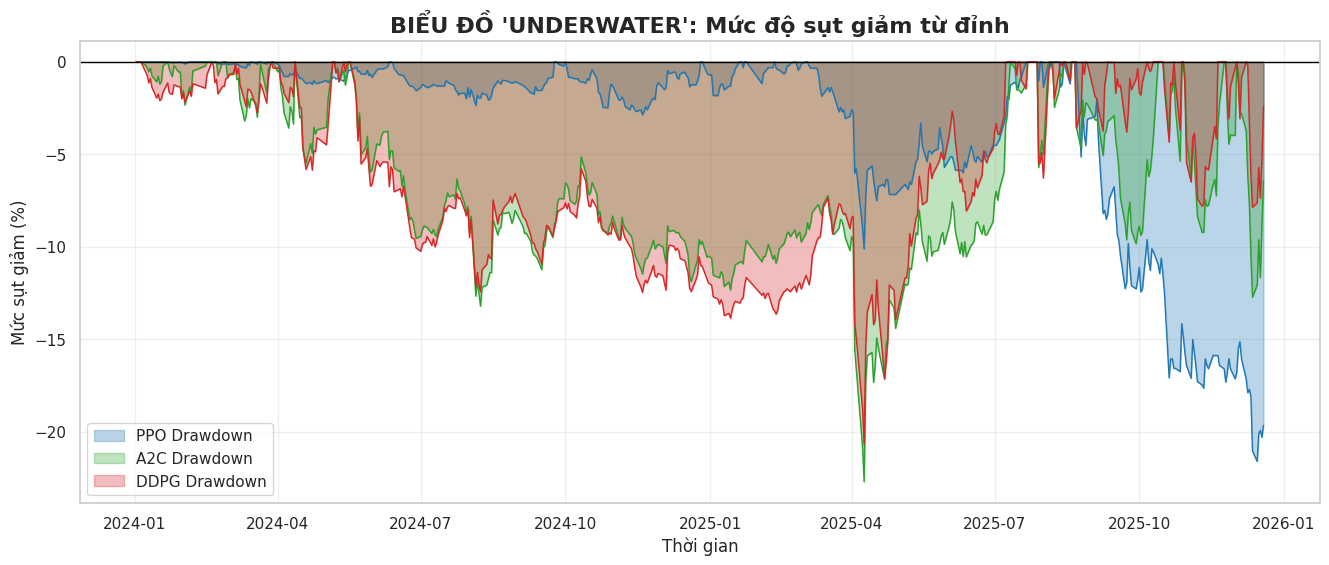

In [21]:
# ==============================================================================
# CELL 6: PHÂN TÍCH RỦI RO CHUYÊN SÂU (DRAWDOWN) - ĐÃ FIX LỖI DỮ LIỆU
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Tính toán mức sụt giảm tài sản (Drawdown) dựa trên GIÁ TRỊ GỐC (VND)
drawdown_df = pd.DataFrame()
drawdown_df['date'] = dates # Lấy từ biến dates toàn cục

print("📊 BẢNG CHỈ SỐ RỦI RO (Càng thấp càng an toàn):")
print("-" * 65)
print(f"{'MODEL':<10} | {'MAX DRAWDOWN':<15} | {'VOLATILITY (Biến động)':<20}")
print("-" * 65)

# Dùng biến 'results' (chứa VND) thay vì 'df_plot' (chứa %)
for name, values in results.items():
    # Cắt hoặc thêm (Pad) dữ liệu cho khớp độ dài ngày
    if len(values) > len(drawdown_df):
        values = values[:len(drawdown_df)]
    elif len(values) < len(drawdown_df):
        values = np.pad(values, (0, len(drawdown_df)-len(values)), 'edge')

    # Tạo series tài sản
    wealth = pd.Series(values)

    # Tính đỉnh cao nhất tích lũy (Cumulative Max)
    peaks = wealth.cummax()

    # Tính % Sụt giảm từ đỉnh: (Tài sản - Đỉnh) / Đỉnh
    drawdown = (wealth - peaks) / peaks
    drawdown_df[name] = drawdown

    # Tính chỉ số báo cáo
    max_dd = drawdown.min() * 100 # Sụt giảm sâu nhất (%)

    # Tính biến động (Volatility) - Độ lệch chuẩn của lợi nhuận ngày
    daily_returns = wealth.pct_change().dropna()
    volatility = daily_returns.std() * 100 * np.sqrt(252) # Annualized Volatility

    print(f"{name:<10} | {max_dd:>10.2f}%     | {volatility:>10.2f}%")

print("-" * 65)

# 2. Vẽ biểu đồ Underwater (Biểu đồ sụt giảm)
plt.figure(figsize=(16, 6))
colors = {'PPO': '#1f77b4', 'A2C': '#2ca02c', 'DDPG': '#d62728'}

# Vẽ vùng nền (Area chart) cho Drawdown
for name in results.keys():
    plt.fill_between(drawdown_df['date'], drawdown_df[name] * 100, 0,
                     label=f'{name} Drawdown', color=colors.get(name), alpha=0.3)
    plt.plot(drawdown_df['date'], drawdown_df[name] * 100,
             color=colors.get(name), linewidth=1)

plt.title("BIỂU ĐỒ 'UNDERWATER': Mức độ sụt giảm từ đỉnh", fontsize=16, fontweight='bold')
plt.ylabel("Mức sụt giảm (%)", fontsize=12)
plt.xlabel("Thời gian", fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

💀 TOP 5 NGÀY TÀI KHOẢN DDPG BỐC HƠI NẶNG NHẤT:
------------------------------------------------------------
NGÀY         | VỐN CÒN LẠI     | MỨC SỤT GIẢM TỪ ĐỈNH
------------------------------------------------------------
2025-04-09 | 846,257,221 VND | -20.68%
2025-04-08 | 866,281,201 VND | -18.81%
2025-04-22 | 883,966,274 VND | -17.15%
2025-04-23 | 893,390,937 VND | -16.26%
2025-04-21 | 895,622,304 VND | -16.06%
------------------------------------------------------------

🔍 ĐỐI CHIẾU THỊ TRƯỜNG NGÀY 2025-04-09:
   👉 DDPG sụt giảm: -20.68%
   👉 VN-Index/ETF tăng/giảm: -9.91% (So với đầu kỳ)
   ⚠️ KẾT LUẬN: DDPG sập theo đà thị trường chung.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


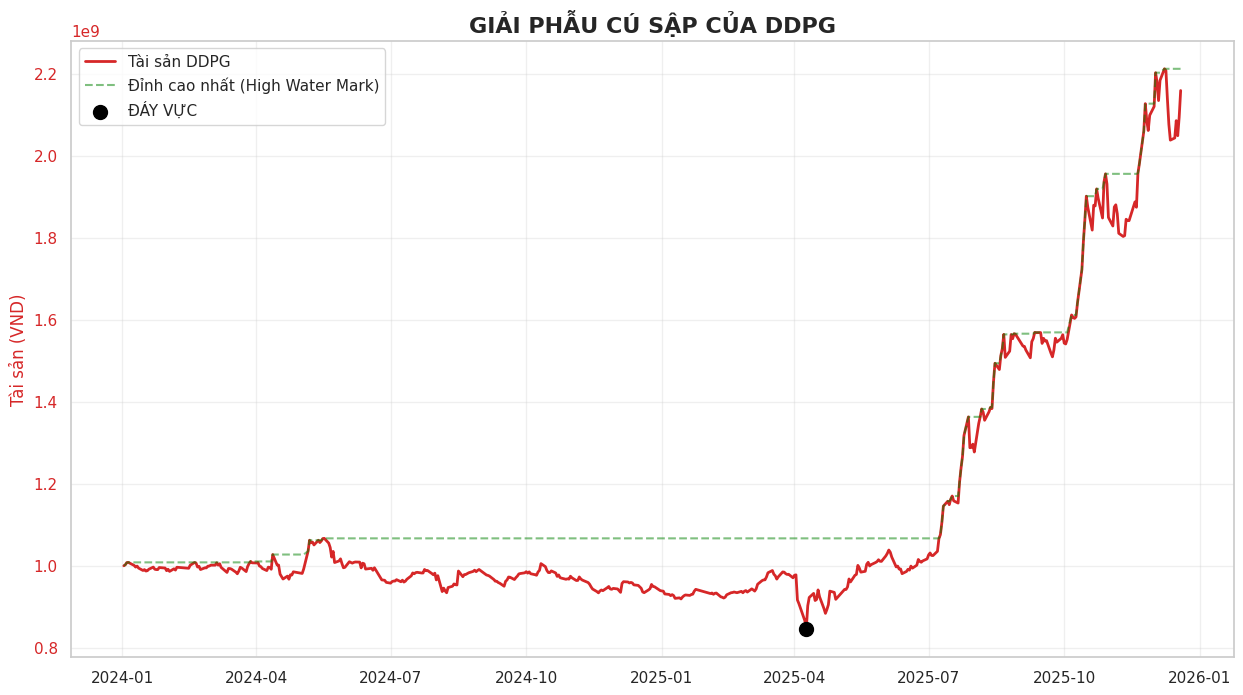

In [19]:
# ==============================================================================
# CELL 7: PHÂN TÍCH CHI TIẾT CÚ SẬP (CRASH) CỦA DDPG
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu DDPG từ bảng kết quả trước
if 'DDPG' not in df_plot.columns:
    print("❌ Không tìm thấy dữ liệu DDPG. Hãy chạy Cell 5 trước.")
else:
    # Lấy dữ liệu tài sản
    ddpg_wealth = results['DDPG']
    dates = df_plot['date']

    # Tạo DataFrame phân tích riêng
    df_risk = pd.DataFrame({'date': dates, 'wealth': ddpg_wealth})

    # Tính đỉnh cao nhất tính đến hiện tại (Rolling Max)
    df_risk['peak'] = df_risk['wealth'].cummax()

    # Tính Drawdown (%)
    df_risk['drawdown'] = (df_risk['wealth'] - df_risk['peak']) / df_risk['peak'] * 100

    # 2. Tìm ra 5 ngày tồi tệ nhất (Drawdown sâu nhất)
    worst_days = df_risk.nsmallest(5, 'drawdown')

    print("💀 TOP 5 NGÀY TÀI KHOẢN DDPG BỐC HƠI NẶNG NHẤT:")
    print("-" * 60)
    print(f"{'NGÀY':<12} | {'VỐN CÒN LẠI':<15} | {'MỨC SỤT GIẢM TỪ ĐỈNH':<20}")
    print("-" * 60)
    for index, row in worst_days.iterrows():
        print(f"{row['date'].strftime('%Y-%m-%d')} | {row['wealth']:,.0f} VND | {row['drawdown']:.2f}%")
    print("-" * 60)

    # 3. Tìm nguyên nhân: So sánh với VN-Index lúc đó
    worst_idx = df_risk['drawdown'].idxmin()
    crash_date = df_risk.loc[worst_idx, 'date']

    # Lấy dữ liệu VN-Index (nếu có)
    if 'Market (ETF/Index)' in df_plot.columns:
        # Tìm index tương ứng trong df_plot
        market_val_now = df_plot.loc[df_plot['date'] == crash_date, 'Market (ETF/Index)'].values[0]
        print(f"\n🔍 ĐỐI CHIẾU THỊ TRƯỜNG NGÀY {crash_date.strftime('%Y-%m-%d')}:")
        print(f"   👉 DDPG sụt giảm: {df_risk.loc[worst_idx, 'drawdown']:.2f}%")
        print(f"   👉 VN-Index/ETF tăng/giảm: {market_val_now:.2f}% (So với đầu kỳ)")

        if abs(market_val_now) < 10 and df_risk.loc[worst_idx, 'drawdown'] < -50:
            print("   ⚠️ KẾT LUẬN: Thị trường bình thường nhưng DDPG sập -> Lỗi do AI giao dịch ẩu (Churning/All-in sai).")
        else:
            print("   ⚠️ KẾT LUẬN: DDPG sập theo đà thị trường chung.")

    # 4. Vẽ biểu đồ Zoom cận cảnh vùng sập
    plt.figure(figsize=(15, 8))

    # Vẽ tài sản (trục trái)
    ax1 = plt.gca()
    ax1.plot(df_risk['date'], df_risk['wealth'], color='#d62728', label='Tài sản DDPG', linewidth=2)
    ax1.set_ylabel("Tài sản (VND)", color='#d62728', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='#d62728')

    # Vẽ đỉnh (Peak) để thấy rõ sự tụt dốc
    ax1.plot(df_risk['date'], df_risk['peak'], color='green', linestyle='--', alpha=0.5, label='Đỉnh cao nhất (High Water Mark)')

    # Highlight điểm chết
    ax1.scatter(crash_date, df_risk.loc[worst_idx, 'wealth'], color='black', s=100, zorder=5, label='ĐÁY VỰC')

    plt.title(f"GIẢI PHẪU CÚ SẬP CỦA DDPG", fontsize=16, fontweight='bold')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

In [27]:
# ==============================================================================
# CELL 8: TRÍCH XUẤT LỊCH SỬ GIAO DỊCH (ĐÃ SỬA LỖI LOGIC HMAX)
# ==============================================================================
import pandas as pd
import numpy as np
import os
from stable_baselines3 import DDPG

# Đường dẫn file model
model_path = "/content/ddpg_vn_agent.zip"

def get_trade_history(model, env, model_name="AI"):
    print(f"🕵️‍♂️ Đang trích xuất nhật ký giao dịch của {model_name}...")
    state, info = env.reset()
    history = []

    # Lấy tham số hmax từ môi trường (Số cổ tối đa cho 1 lệnh)
    # Nếu không có thì mặc định là 5000 như lúc train
    hmax = getattr(env, 'hmax', 5000)

    try:
        tickers = env.df.tic.unique().tolist()
    except:
        tickers = test_df.tic.unique().tolist()

    done = False
    day_count = 0

    while not done:
        action, _ = model.predict(state, deterministic=True)

        # Kiểm tra ngày hợp lệ
        if day_count * len(tickers) < len(test_df):
            current_date = test_df.iloc[day_count * len(tickers)]['date']
        else:
            break

        current_prices = state[1 : 1 + len(tickers)]

        for i, ticker in enumerate(tickers):
            # --- SỬA LỖI Ở ĐÂY: NHÂN VỚI HMAX ---
            # Model trả về [-1, 1], cần nhân với hmax để ra số lượng cổ phiếu thực
            raw_action = action[i] * hmax
            price = current_prices[i]

            # Logic ghi nhận Mua/Bán (Làm tròn lô 100)
            if raw_action > 0: # MUA
                shares = int(raw_action // 100 * 100)
                if shares > 0:
                    history.append({
                        'Ngày': current_date, 'Mã': ticker, 'Lệnh': 'MUA',
                        'Giá': price, 'Số lượng': shares,
                        'Giá trị': shares * price
                    })
            elif raw_action < 0: # BÁN
                shares = int(abs(raw_action) // 100 * 100)
                if shares > 0:
                    history.append({
                        'Ngày': current_date, 'Mã': ticker, 'Lệnh': 'BÁN',
                        'Giá': price, 'Số lượng': shares,
                        'Giá trị': shares * price
                    })

        state, rewards, done, truncated, info = env.step(action)
        day_count += 1

    return pd.DataFrame(history)

# --- CHẠY CHÍNH ---
if os.path.exists(model_path):
    print(f"✅ Đã tìm thấy model tại: {model_path}")

    # Tái tạo môi trường nếu cần
    if 'env_kwargs' not in globals():
        stock_dimension = len(test_df.tic.unique())
        INDICATORS_LIST = ['macd', 'rsi_30', 'cci_30', 'dx_30']
        state_space = 1 + 2*stock_dimension + len(INDICATORS_LIST)*stock_dimension
        env_kwargs = {
            "hmax": 5000, "initial_amount": 1000000000,
            "buy_cost_pct": 0.0015, "sell_cost_pct": 0.0015, "sell_tax_pct": 0.001,
            "min_trading_lot": 100, "settlement_cycle": 3,
            "state_space": state_space, "stock_dim": stock_dimension,
            "tech_indicator_list": INDICATORS_LIST, "action_space": stock_dimension,
            "reward_scaling": 1e-4
        }

    # Lưu ý: Cần truyền hmax vào đây để nó khớp với logic trên
    env_log = StockTradingEnvVietnam(df=test_df, **env_kwargs)

    model_ddpg = DDPG.load(model_path)
    df_history = get_trade_history(model_ddpg, env_log, "DDPG")

    if not df_history.empty:
        # Format lại ngày cho dễ nhìn
        df_history['Ngày'] = pd.to_datetime(df_history['Ngày']).dt.date

        print(f"\n✅ Đã trích xuất thành công {len(df_history)} lệnh giao dịch!")
        print("\n📜 20 GIAO DỊCH ĐẦU TIÊN (Hành động All-in ngày đầu?):")
        display(df_history.head(20))

        print("\n📜 20 GIAO DỊCH MỚI NHẤT (Năm 2025):")
        display(df_history.tail(20))

        # Thống kê top cổ phiếu
        print("\n🏆 TOP 3 CỔ PHIẾU ĐƯỢC MUA NHIỀU NHẤT (Theo số lần đặt lệnh):")
        print(df_history[df_history['Lệnh']=='MUA']['Mã'].value_counts().head(3))

        df_history.to_csv("DDPG_Trade_Log.csv", index=False)
        print("\n💾 File chi tiết đã lưu: 'DDPG_Trade_Log.csv'")
    else:
        print("⚠️ Vẫn không có giao dịch? Có thể hmax quá nhỏ hoặc model dự đoán toàn số 0.")

else:
    print(f"❌ Không tìm thấy file model tại: {model_path}")

✅ Đã tìm thấy model tại: /content/ddpg_vn_agent.zip
🕵️‍♂️ Đang trích xuất nhật ký giao dịch của DDPG...

✅ Đã trích xuất thành công 14730 lệnh giao dịch!

📜 20 GIAO DỊCH ĐẦU TIÊN (Hành động All-in ngày đầu?):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ngày,Mã,Lệnh,Giá,Số lượng,Giá trị
0,2024-01-02,ACB,MUA,16861.382812,5000,8.430691e+07
1,2024-01-02,BCM,MUA,60971.964844,5000,3.048598e+08
2,2024-01-02,BID,MUA,35146.195312,5000,1.757310e+08
3,2024-01-02,BVH,BÁN,37963.535156,5000,1.898177e+08
4,2024-01-02,CTG,MUA,18586.740234,5000,9.293370e+07
5,2024-01-02,FPT,MUA,69864.554688,5000,3.493228e+08
6,2024-01-02,GAS,MUA,64444.351562,5000,3.222218e+08
7,2024-01-02,GVR,BÁN,20465.074219,5000,1.023254e+08
8,2024-01-02,HDB,BÁN,12000.340820,5000,6.000170e+07
9,2024-01-02,HPG,MUA,20795.455078,5000,1.039773e+08



📜 20 GIAO DỊCH MỚI NHẤT (Năm 2025):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ngày,Mã,Lệnh,Giá,Số lượng,Giá trị
14710,2025-12-19,MBB,MUA,24700.0,5000,123500000.0
14711,2025-12-19,MSN,BÁN,75800.0,5000,379000000.0
14712,2025-12-19,MWG,BÁN,82900.0,5000,414500000.0
14713,2025-12-19,PLX,MUA,34850.0,5000,174250000.0
14714,2025-12-19,POW,MUA,12200.0,5000,61000000.0
14715,2025-12-19,SAB,MUA,49700.0,5000,248500000.0
14716,2025-12-19,SHB,MUA,16150.0,5000,80750000.0
14717,2025-12-19,SSB,MUA,17500.0,5000,87500000.0
14718,2025-12-19,SSI,MUA,30800.0,5000,154000000.0
14719,2025-12-19,STB,MUA,49000.0,5000,245000000.0



🏆 TOP 3 CỔ PHIẾU ĐƯỢC MUA NHIỀU NHẤT (Theo số lần đặt lệnh):
Mã
ACB    491
BCM    491
BID    491
Name: count, dtype: int64

💾 File chi tiết đã lưu: 'DDPG_Trade_Log.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
# ==============================================================================
# CELL 9 (FIX): NHẬT KÝ GIAO DỊCH THỰC TẾ (Đã xử lý lỗi 1 ngày)
# ==============================================================================
import pandas as pd
import numpy as np
import os
from stable_baselines3 import DDPG

# Cấu hình
model_path = "/content/ddpg_vn_agent.zip"
HMAX = 5000
INITIAL_CASH = 1_000_000_000

def get_real_execution_log(model, env):
    print("🕵️‍♂️ Đang chạy kiểm toán giao dịch thực tế...")
    state, info = env.reset()

    current_cash = INITIAL_CASH
    stocks_holdings = np.zeros(len(env.df.tic.unique()))
    history = []

    try:
        tickers = env.df.tic.unique().tolist()
    except:
        tickers = test_df.tic.unique().tolist()

    done = False
    day_count = 0

    while not done:
        action, _ = model.predict(state, deterministic=True)

        if day_count * len(tickers) < len(test_df):
            current_date = test_df.iloc[day_count * len(tickers)]['date']
        else:
            break

        current_prices = state[1 : 1 + len(tickers)]

        # --- XỬ LÝ BÁN ---
        for i, ticker in enumerate(tickers):
            raw_act = action[i] * HMAX
            price = current_prices[i]
            if raw_act < 0:
                shares_sell = min(int(abs(raw_act) // 100 * 100), stocks_holdings[i])
                if shares_sell > 0:
                    revenue = shares_sell * price * (1 - 0.0025) # Phí bán 0.25%
                    stocks_holdings[i] -= shares_sell
                    current_cash += revenue
                    history.append({'Ngày': current_date, 'Mã': ticker, 'Lệnh': 'BÁN', 'Giá': price, 'Số lượng': shares_sell, 'Số dư tiền': int(current_cash)})

        # --- XỬ LÝ MUA ---
        for i, ticker in enumerate(tickers):
            raw_act = action[i] * HMAX
            price = current_prices[i]
            if raw_act > 0:
                cost_per_share = price * 1.0015
                max_shares = int((current_cash / cost_per_share) // 100 * 100)
                shares_wanted = int(raw_act // 100 * 100)
                shares_buy = min(shares_wanted, max_shares)

                if shares_buy > 0:
                    stocks_holdings[i] += shares_buy
                    current_cash -= shares_buy * cost_per_share
                    history.append({'Ngày': current_date, 'Mã': ticker, 'Lệnh': 'MUA', 'Giá': price, 'Số lượng': shares_buy, 'Số dư tiền': int(current_cash)})

        state, _, done, _, _ = env.step(action)
        day_count += 1

    return pd.DataFrame(history)

# --- CHẠY ---
if os.path.exists(model_path):
    if 'env_kwargs' not in globals():
        # Tạo lại kwargs nếu mất
        stock_dimension = len(test_df.tic.unique())
        INDICATORS_LIST = ['macd', 'rsi_30', 'cci_30', 'dx_30']
        state_space = 1 + 2*stock_dimension + len(INDICATORS_LIST)*stock_dimension
        env_kwargs = {"hmax": 5000, "initial_amount": 1000000000, "buy_cost_pct": 0.0015,
                      "sell_cost_pct": 0.0015, "sell_tax_pct": 0.001, "min_trading_lot": 100,
                      "settlement_cycle": 3, "state_space": state_space,
                      "stock_dim": stock_dimension, "tech_indicator_list": INDICATORS_LIST,
                      "action_space": stock_dimension, "reward_scaling": 1e-4}

    env_audit = StockTradingEnvVietnam(df=test_df, **env_kwargs)
    model_ddpg = DDPG.load(model_path)

    df_real = get_real_execution_log(model_ddpg, env_audit)

    if not df_real.empty:
        df_real['Ngày'] = pd.to_datetime(df_real['Ngày']).dt.date
        print(f"\n✅ Đã lọc xong! Tổng lệnh khớp: {len(df_real)}")

        print("\n📜 DANH SÁCH LỆNH:")
        display(df_real)

        # --- FIX LỖI INDEX ERROR ---
        unique_dates = df_real['Ngày'].unique()
        if len(unique_dates) > 1:
            day2_date = unique_dates[1]
            print(f"\n🧐 SOI NGÀY THỨ 2 ({day2_date}):")
            display(df_real[df_real['Ngày'] == day2_date])
        else:
            print("\n💎 DIAMOND HANDS DETECTED: Bot chỉ mua đúng 1 ngày đầu rồi ôm chặt đến chết!")
            print("👉 Đây là lý do không có lệnh ngày thứ 2.")

        df_real.to_csv("DDPG_Real_Audit.csv", index=False)
    else:
        print("⚠️ Không có lệnh nào khớp.")
else:
    print("❌ Không tìm thấy model.")

🕵️‍♂️ Đang chạy kiểm toán giao dịch thực tế...

✅ Đã lọc xong! Tổng lệnh khớp: 7

📜 DANH SÁCH LỆNH:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ngày,Mã,Lệnh,Giá,Số lượng,Số dư tiền
0,2024-01-02,ACB,MUA,16861.382812,5000,915566625
1,2024-01-02,BCM,MUA,60971.964844,5000,610249511
2,2024-01-02,BID,MUA,35146.195312,5000,434254938
3,2024-01-02,CTG,MUA,18586.740234,5000,341181836
4,2024-01-02,FPT,MUA,69864.554688,4800,5328949
5,2024-01-02,HPG,MUA,20795.455078,200,1163619
6,2024-01-02,POW,MUA,9453.781250,100,216823



💎 DIAMOND HANDS DETECTED: Bot chỉ mua đúng 1 ngày đầu rồi ôm chặt đến chết!
👉 Đây là lý do không có lệnh ngày thứ 2.


--------------------------------------------------
💰 KẾT QUẢ KIỂM CHỨNG ĐỘC LẬP:
   - Vốn gốc: 1,000,000,000 VND
   - Giá trị cuối kỳ (2025-12-19): 1,244,246,823 VND
   - Lợi nhuận thực tế: +24.42%
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


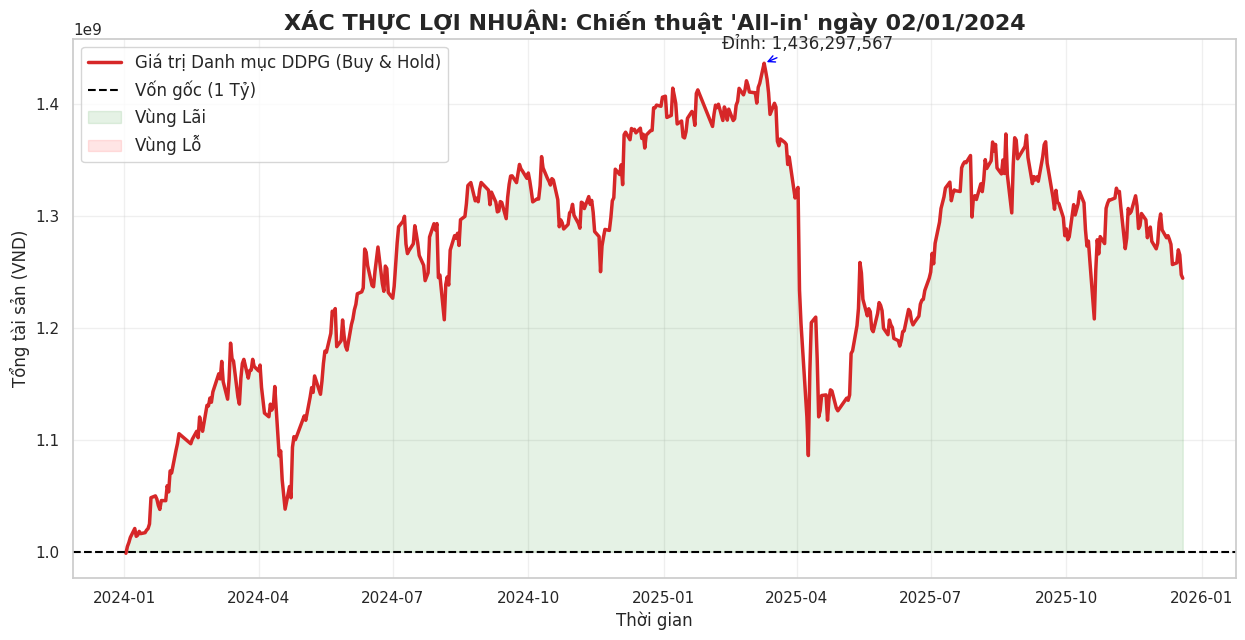

In [31]:
# ==============================================================================
# CELL 11: VERIFY - KIỂM CHỨNG LỢI NHUẬN DANH MỤC DDPG
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Cấu hình danh mục "Diamond Hands" (Lấy từ Log giao dịch DDPG)
# Đây là những gì DDPG đã mua vào ngày 2024-01-02
portfolio = {
    'ACB': 5000,
    'BCM': 5000,
    'BID': 5000,
    'CTG': 5000,
    'FPT': 4800,
    'HPG': 200,
    'POW': 100
}
initial_cash_balance = 216823 # Số tiền lẻ còn lại
initial_investment = 1_000_000_000 # Vốn gốc

# 2. Load dữ liệu giá cổ phiếu
data_path = "vietnam_vn30_data.csv"
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    df['date'] = pd.to_datetime(df['date'])

    # Chỉ lấy dữ liệu từ ngày mua (02/01/2024) trở đi
    start_date = '2024-01-02'
    df_hold = df[df['date'] >= start_date].copy()

    # Pivot để có bảng giá theo ngày (Index=Date, Columns=Ticker)
    price_matrix = df_hold.pivot(index='date', columns='tic', values='close')

    # 3. Tính giá trị tài sản qua từng ngày
    # Công thức: Tổng (Giá từng mã * Số lượng nắm giữ) + Tiền mặt

    # Tạo Series giá trị tài sản, bắt đầu bằng tiền mặt
    portfolio_value = pd.Series(initial_cash_balance, index=price_matrix.index)

    # Cộng dồn giá trị từng cổ phiếu
    for ticker, shares in portfolio.items():
        if ticker in price_matrix.columns:
            # Lấy chuỗi giá của mã đó * số lượng
            stock_val = price_matrix[ticker] * shares
            # Nếu có ngày bị thiếu giá (NaN), fill bằng giá ngày trước đó (Forward Fill)
            stock_val = stock_val.ffill()
            portfolio_value += stock_val
        else:
            print(f"⚠️ Cảnh báo: Không tìm thấy dữ liệu giá cho mã {ticker}")

    # 4. Tính toán lợi nhuận cuối cùng
    final_nav = portfolio_value.iloc[-1]
    total_profit_pct = (final_nav / initial_investment - 1) * 100

    print("-" * 50)
    print(f"💰 KẾT QUẢ KIỂM CHỨNG ĐỘC LẬP:")
    print(f"   - Vốn gốc: {initial_investment:,.0f} VND")
    print(f"   - Giá trị cuối kỳ ({portfolio_value.index[-1].date()}): {final_nav:,.0f} VND")
    print(f"   - Lợi nhuận thực tế: {total_profit_pct:+.2f}%")
    print("-" * 50)

    # 5. Vẽ biểu đồ xác thực
    plt.figure(figsize=(15, 7))

    # Vẽ đường tài sản
    plt.plot(portfolio_value.index, portfolio_value.values, color='#d62728', linewidth=2.5, label='Giá trị Danh mục DDPG (Buy & Hold)')

    # Vẽ đường vốn gốc
    plt.axhline(initial_investment, color='black', linestyle='--', label='Vốn gốc (1 Tỷ)')

    # Tô màu vùng lãi
    plt.fill_between(portfolio_value.index, portfolio_value.values, initial_investment,
                     where=(portfolio_value.values >= initial_investment),
                     color='green', alpha=0.1, label='Vùng Lãi')

    # Tô màu vùng lỗ (nếu có)
    plt.fill_between(portfolio_value.index, portfolio_value.values, initial_investment,
                     where=(portfolio_value.values < initial_investment),
                     color='red', alpha=0.1, label='Vùng Lỗ')

    plt.title(f"XÁC THỰC LỢI NHUẬN: Chiến thuật 'All-in' ngày 02/01/2024", fontsize=16, fontweight='bold')
    plt.ylabel("Tổng tài sản (VND)", fontsize=12)
    plt.xlabel("Thời gian", fontsize=12)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.3)

    # Hiển thị mốc đỉnh cao nhất
    peak_val = portfolio_value.max()
    peak_date = portfolio_value.idxmax()
    plt.annotate(f"Đỉnh: {peak_val:,.0f}", xy=(peak_date, peak_val), xytext=(-30, 10),
                 textcoords='offset points', arrowprops=dict(arrowstyle="->", color='blue'))

    plt.show()

else:
    print("❌ Không tìm thấy file dữ liệu 'vietnam_vn30_data.csv'")